In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    )
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

data_path = Path("../data/heart_disease_uci.csv")
df = pd.read_csv(data_path)

X_full = df.drop(["num", "id", "dataset"], axis=1)
X_full = pd.get_dummies(X_full, drop_first=True)
y_full = df["num"].apply(lambda x: 1 if x > 0 else 0)

print("Loaded dataset shape:", df.shape)
print("Enhanced feature matrix shape:", X_full.shape)
print("Positive class ratio:", y_full.mean().round(3))

Loaded dataset shape: (920, 16)
Enhanced feature matrix shape: (920, 18)
Positive class ratio: 0.553


In [7]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full,
)

log_reg_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

log_reg_pipeline.fit(X_train2, y_train2)

y_pred2 = log_reg_pipeline.predict(X_test2)
y_prob2 = log_reg_pipeline.predict_proba(X_test2)[:, 1]

metrics_baseline = {
    "accuracy": accuracy_score(y_test2, y_pred2),
    "precision": precision_score(y_test2, y_pred2),
    "recall": recall_score(y_test2, y_pred2),
    "f1": f1_score(y_test2, y_pred2),
    "roc_auc": roc_auc_score(y_test2, y_prob2),
}

print("Baseline logistic regression metrics:")
for k, v in metrics_baseline.items():
    print(f"{k:>10}: {v:.4f}")

Baseline logistic regression metrics:
  accuracy: 0.8370
 precision: 0.8333
    recall: 0.8824
        f1: 0.8571
   roc_auc: 0.9029


In [8]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)

grid.fit(X_train2, y_train2)

print("Best params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

Best params: {'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'lbfgs'}
Best CV F1: 0.8426


In [9]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test2)
y_prob_best = best_model.predict_proba(X_test2)[:, 1]

metrics_best = {
    "accuracy": accuracy_score(y_test2, y_pred_best),
    "precision": precision_score(y_test2, y_pred_best),
    "recall": recall_score(y_test2, y_pred_best),
    "f1": f1_score(y_test2, y_pred_best),
    "roc_auc": roc_auc_score(y_test2, y_prob_best),
}

print("\nTuned logistic regression metrics:")
for k, v in metrics_best.items():
    print(f"{k:>10}: {v:.4f}")

print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_test2, y_pred_best))

print("Confusion Matrix (Tuned Model):\n", confusion_matrix(y_test2, y_pred_best))


Tuned logistic regression metrics:
  accuracy: 0.8261
 precision: 0.8241
    recall: 0.8725
        f1: 0.8476
   roc_auc: 0.8993

Classification Report (Tuned Model):

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        82
           1       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184

Confusion Matrix (Tuned Model):
 [[63 19]
 [13 89]]


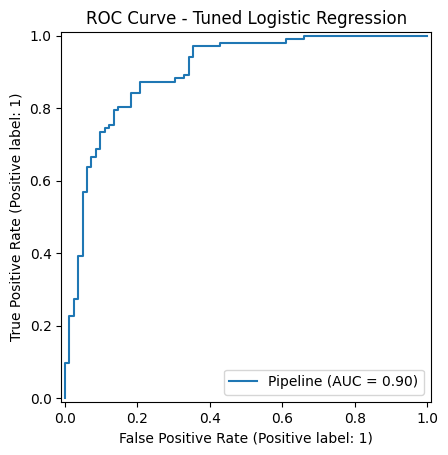

Threshold analysis (choose trade-off based on objective):
   threshold  precision    recall        f1
0        0.3   0.724638  0.980392  0.833333
1        0.4   0.768595  0.911765  0.834081
2        0.5   0.824074  0.872549  0.847619
3        0.6   0.872340  0.803922  0.836735
4        0.7   0.917808  0.656863  0.765714


In [10]:
RocCurveDisplay.from_estimator(best_model, X_test2, y_test2)
plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    threshold_results.append(
        {
            "threshold": t,
            "precision": precision_score(y_test2, y_pred_t),
            "recall": recall_score(y_test2, y_pred_t),
            "f1": f1_score(y_test2, y_pred_t),
        }
    )

threshold_df = pd.DataFrame(threshold_results)
print("Threshold analysis (choose trade-off based on objective):")
print(threshold_df)

In [11]:
feature_names = X_full.columns
coefficients = best_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients),
    }
).sort_values("abs_coefficient", ascending=False)

print("Top 10 most influential features (by |coefficient|):")
print(coef_df[["feature", "coefficient"]].head(10))

Top 10 most influential features (by |coefficient|):
               feature  coefficient
7   cp_atypical angina    -0.372443
13          exang_True     0.299826
6             sex_Male     0.266770
4              oldpeak     0.237795
14          slope_flat     0.236615
3               thalch    -0.220749
2                 chol    -0.216979
5                   ca     0.211195
8       cp_non-anginal    -0.205567
0                  age     0.201282
